In [1]:
import sys
import asyncio
from pathlib import Path
import json
import textwrap
import subprocess

import pandas as pd
import matplotlib.pyplot as plt

from agents.mcp import MCPServerStdio

This app does orchestration and UI logic. It uses a local Ollama model to take in a prompt and generate a dictionary that can query data from nfl_data_py via the executor. 

It calls MCP client, converts rows into dataframe, and generates bar charts.


In [2]:
OLLAMA_BIN = "/usr/local/bin/ollama"

def ollama_chat(prompt: str, model: str = "llama3.1:8b") -> str:
    """
    Call a local Ollama model and return its text response as a string.
    """
    proc = subprocess.run(
        [OLLAMA_BIN, "run", model],
        input=prompt.encode("utf-8"),
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
    )
    if proc.returncode != 0:
        print("Ollama error:", proc.stderr.decode("utf-8"))
        raise RuntimeError("Ollama call failed")
    return proc.stdout.decode("utf-8")

In [3]:
from pathlib import Path
import json

PLANNER_PROMPT = Path("prompts/planner_system.txt").read_text()

def plan_metric_from_question(question: str, model: str = "llama3.1:8b") -> dict:
    """
    Use the local model to decide:
      - seasons (list[int])
      - season_type ("REG" or "POST")
      - query string for MetricsExecutor
    """
    prompt = (
        PLANNER_PROMPT
        + "\n\nUser question:\n"
        + question
        + "\n\nJSON only:\n"
    )

    raw = ollama_chat(prompt, model=model)

    # Parse JSON from model output
    try:
        start = raw.index("{")
        end = raw.rindex("}") + 1
        plan = json.loads(raw[start:end])
    except Exception as e:
        print("Planner raw output:\n", raw)
        raise RuntimeError(f"Failed to parse planner JSON: {e}")

    # --- Normalize / defaults ---

    if "seasons" not in plan:
        if "season" in plan:
            val = plan["season"]
            plan["seasons"] = [int(x) for x in val] if isinstance(val, list) else [int(val)]
        else:
            plan["seasons"] = [2023]

    stype = str(plan.get("season_type", "REG")).upper()
    if stype not in ("REG", "POST"):
        stype = "REG"
    plan["season_type"] = stype

    if "query" not in plan or not str(plan["query"]).strip():
        plan["query"] = "ranked epa per play"

    # --- Deterministic disambiguation ---
    q_lower = question.lower()

    # QB intent: if they mention QB/quarterback/passer, default to QB EPA unless CPOE requested
    if any(k in q_lower for k in ["qb", "quarterback", "quarterbacks", "passer"]):
        if "cpoe" in q_lower or "completion percentage over expected" in q_lower:
            plan["query"] = "qb ranked by cpoe"
        else:
            # If user explicitly mentions dropback/pass, it's still QB EPA per pass
            plan["query"] = "qb ranked by epa per pass"

    # Team offensive EPA ambiguity: "offensive epa" defaults to EPA/play unless dropback/pass specified
    elif "offensive epa" in q_lower or ("offense" in q_lower and "epa" in q_lower):
        if "dropback" in q_lower or "per pass" in q_lower:
            plan["query"] = "epa per dropback"
        else:
            plan["query"] = "ranked epa per play"

    return plan

In [4]:
def unpack_tool_result(tool_response):
    """
    Normalize MCP tool responses so we always get the actual payload dict.

    FastMCP typically wraps your return value as:
        structuredContent = {"result": <your_return_value>}
    But we also guard for errors and missing structuredContent.
    """
    if getattr(tool_response, "isError", False):
        raise RuntimeError(f"Tool call failed: {tool_response.content}")

    sc = tool_response.structuredContent
    if sc is None:
        raise RuntimeError(f"No structuredContent in tool response: {tool_response}")

    if isinstance(sc, dict) and "result" in sc:
        return sc["result"]
    return sc

In [5]:
async def run_planned_metric(question: str):
    """
    Full pipeline:
      1. Ask local model to plan seasons/season_type/query.
      2. Use MCP to load_pbp and compute_metric.
      3. Return the plan, summary, and rows.
    """
    plan = plan_metric_from_question(question)
    seasons = plan["seasons"]
    season_type = plan["season_type"]
    query = plan["query"]

    print("Plan from model:", plan)

    server_path = Path("mcp_nfl_metrics_server.py").resolve()
    async with MCPServerStdio(
        name="NFL Metrics MCP",
        params={
            "command": sys.executable,
            "args": [str(server_path), "stdio"],
        },
        cache_tools_list=True,
    ) as mcp_server:
        # 1) Load play-by-play for those seasons
        load_result = await mcp_server.call_tool(
            "load_pbp",
            {
                "seasons": seasons,
                "season_type": season_type,
            },
        )

        load_payload = unpack_tool_result(load_result)
        print("load_pbp structured payload:", load_payload)

        session_id = load_payload["session_id"]
        rows_loaded = load_payload["rows"]
        print(f"Loaded {rows_loaded} rows, session_id={session_id}")

        # 2) Compute requested metric
        metric_result = await mcp_server.call_tool(
            "compute_metric",
            {
                "session_id": session_id,
                "query": query,
            },
        )

        metric_payload = unpack_tool_result(metric_result)
        summary = metric_payload["summary"]
        rows = metric_payload["rows"]

        return plan, summary, rows

In [6]:
from IPython.display import display
import pandas as pd
import matplotlib.pyplot as plt

def summarize_with_table_and_chart(summary: str, rows: list, top_n: int | None = None):
    """
    Show:
      - A short text summary
      - A table
      - A bar chart

    Works for:
      - Team EPA metrics (rank, team, epa_per_play)
      - QB metrics (rank, qb, team, dropbacks, epa_per_pass, cpoe)

    top_n:
      - If None: show ALL rows.
      - If an int: show only the top_n by rank.
    """
    if not rows:
        print("Data not available.")
        return pd.DataFrame()

    # Build DataFrame from rows
    df = pd.DataFrame(rows)

    # --- Detect whether this is a QB result or a team result ---
    is_qb = "qb" in df.columns

    if is_qb:
        # QB metrics
        # Decide which metric to use for the chart: prefer cpoe if it has data, else epa_per_pass
        if "cpoe" in df.columns and df["cpoe"].notna().any():
            metric_col = "cpoe"
        else:
            metric_col = "epa_per_pass"

        # Columns we care about for display (keep only those that exist)
        cols = ["rank", "qb", "team", "dropbacks", "epa_per_pass", "cpoe"]
        cols = [c for c in cols if c in df.columns]

        # Sort by rank, then optionally limit
        df = df[cols].sort_values("rank")
    else:
        # Team metrics (current behavior)
        metric_col = "epa_per_play"
        expected_cols = ["rank", "team", metric_col]
        missing = [c for c in expected_cols if c not in df.columns]
        if missing:
            raise ValueError(f"Missing columns in rows: {missing}")
        df = df[expected_cols].sort_values("rank")

    # Apply limit only if top_n is specified
    if top_n is not None:
        df = df.head(top_n)

    # --- Summary ---
    print(summary.strip(), "\n")

    # --- Table ---
    display(df)

    # --- Bar chart ---
    label_col = "qb" if is_qb else "team"

    # Drop rows missing either the label or the metric
    df_plot = (
        df
        .dropna(subset=[label_col, metric_col])
        .sort_values(metric_col, ascending=True)
    )
    
    plt.figure(figsize=(6, max(4, len(df_plot) * 0.3)))
    plt.barh(df_plot[label_col].astype(str), df_plot[metric_col])
    plt.xlabel(metric_col)
    
    title_prefix = "QB" if is_qb else "Team"
    plt.title(f"{title_prefix} ranking by {metric_col}")
    
    plt.tight_layout()
    plt.show()

    return df

Plan from model: {'seasons': [2025], 'season_type': 'REG', 'query': 'ranked epa per play'}
load_pbp structured payload: {'session_id': '21b904c7-8cea-4a3a-be8e-20c381444a54', 'rows': 41653}
Loaded 41653 rows, session_id=21b904c7-8cea-4a3a-be8e-20c381444a54
Computed team-level offensive EPA per play. Rank 1 is highest (best) EPA/play for offense. Includes a 'plays' column for sample size context. 



,rank,team,epa_per_play
0,1,buf,0.125950
1,2,gb,0.110353
2,3,dal,0.108213
3,4,ind,0.101848
4,5,la,0.101837
5,6,sf,0.092793
6,7,ne,0.086206
7,8,det,0.065952
8,9,kc,0.062433
9,10,sea,0.056984


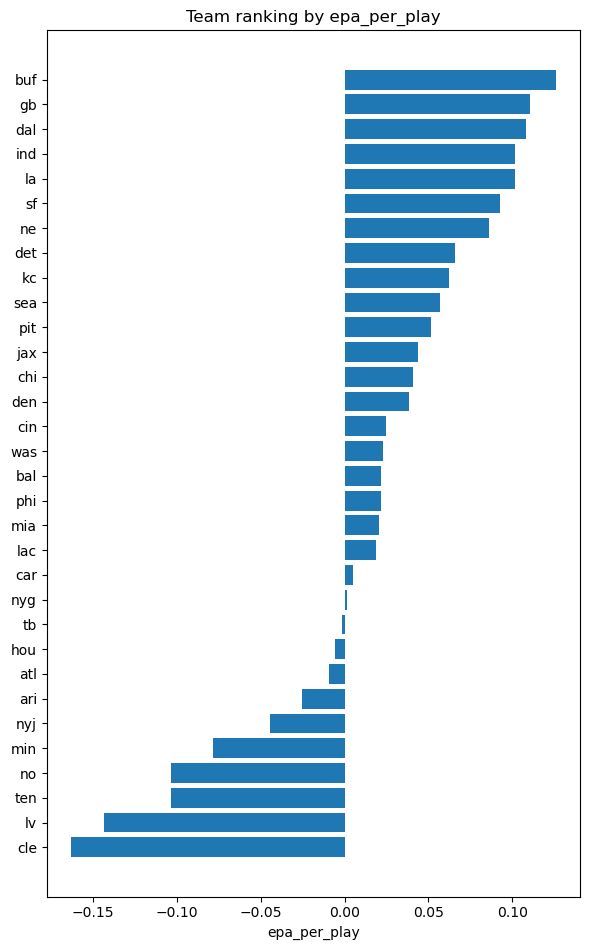

In [7]:
question = "For the 2025 regular season, which offenses have the best EPA per play, and what does that say about their performance?"

plan, summary, rows = await run_planned_metric(question)
df_top = summarize_with_table_and_chart(summary, rows, top_n=None)

In [8]:
def explain_metric(question: str, plan: dict, summary: str, rows: list, model: str = "llama3.1:8b") -> str:
    table_text = pd.DataFrame(rows[:5])[["rank", "team", "epa_per_play"]].to_string(index=False)

    prompt = f"""
    You are an NFL analytics assistant.

    The user asked:
    {question}

    We used a metrics engine with this plan:
    seasons = {plan["seasons"]}
    season_type = "{plan["season_type"]}"
    query = "{plan["query"]}"

    The metrics engine returned this summary:
    {summary}

    And these top rows (tabular data):
    {table_text}

    Answer the user's question in a concise way (1–3 short paragraphs).
    """
    return ollama_chat(textwrap.dedent(prompt), model=model)

In [9]:
question = "For the 2025 regular season, rank quarterbacks by EPA per pass play"
plan = plan_metric_from_question(question)
print(plan)

{'seasons': [2025], 'season_type': 'REG', 'query': 'qb ranked by epa per pass'}


In [10]:
import sys
from pathlib import Path
from agents.mcp import MCPServerStdio

server_path = Path("mcp_nfl_metrics_server.py").resolve()
print("Using server:", server_path)

async with MCPServerStdio(
    name="NFL Metrics MCP",
    params={
        "command": sys.executable,
        "args": [str(server_path), "stdio"],
    },
    cache_tools_list=True,
) as mcp:
    result = await mcp.call_tool(
        "load_pbp",
        {"seasons": [2025], "season_type": "REG"},
    )

    print("Raw structuredContent:")
    print(result.structuredContent)

Using server: /Users/kevinstrouse/Desktop/NFL Agent/mcp_nfl_metrics_server.py
Raw structuredContent:
{'result': {'session_id': '07367229-a5e6-425d-b505-91db3b2d6761', 'rows': 41653}}


In [11]:
question = "Show offensive epa for 2025 season."

plan = plan_metric_from_question(question)
print("PLAN:", plan)

plan, summary, rows = await run_planned_metric(question)
print("SUMMARY:", summary)
print("ROWS:", len(rows))
if rows:
    print("FIRST ROW:", rows[0])

PLAN: {'seasons': [2025], 'season_type': 'REG', 'query': 'offensive success rate'}
Plan from model: {'seasons': [2025], 'season_type': 'REG', 'query': 'epa per dropback'}
load_pbp structured payload: {'session_id': '8304a89b-64a2-4f6c-a4c9-a8762b0229e4', 'rows': 41653}
Loaded 41653 rows, session_id=8304a89b-64a2-4f6c-a4c9-a8762b0229e4
SUMMARY: Computed team-level offensive EPA per dropback. Rank 1 is highest (best) EPA/dropback.
ROWS: 32
FIRST ROW: {'rank': 1, 'team': 'gb', 'dropbacks': 505, 'epa_per_dropback': 0.2766965627670288}


In [13]:
from metrics_executor import MetricsExecutor
import polars as pl

df = pl.DataFrame({
    "season":[2025,2025],
    "posteam":["gb","gb"],
    "defteam":["chi","chi"],
    "epa":[0.3,-0.1],
    "pass_attempt":[1,0],
    "passer_player_name":["Jordan Love", None],
    "cpoe":[0.05, None],
})

ex = MetricsExecutor(df)
out, summary = ex.execute("ranked epa per play")
print(summary)
print(out)

Computed team-level offensive EPA per play. Rank 1 is highest (best) EPA/play for offense. Includes a 'plays' column for sample size context.
shape: (1, 4)
┌──────┬──────┬──────────────┬───────┐
│ rank ┆ team ┆ epa_per_play ┆ plays │
│ ---  ┆ ---  ┆ ---          ┆ ---   │
│ i64  ┆ str  ┆ f64          ┆ u32   │
╞══════╪══════╪══════════════╪═══════╡
│ 1    ┆ gb   ┆ 0.1          ┆ 2     │
└──────┴──────┴──────────────┴───────┘
